# GoPay Google Play Review - Bag of Words (BoW)

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `04 - Bag of Words`

This notebook continues from the preprocessing process covered in [3-Gopay-Review-Preprocessing.ipynb](https://colab.research.google.com/drive/1Iwg8LQ69nvhEtv6wE4Ou7uM2hySBrhKd)

---

## Objective

Convert the cleaned GoPay review text into numerical feature vectors using **Bag of Words (BoW)**. This is the first step in feature extraction before moving on to TF-IDF weighting.

## Why BoW Before TF-IDF?

| Step | Method | What It Captures |
|------|--------|------------------|
| 1 | **Bag of Words** | Raw term frequency per document |
| 2 | **TF-IDF** | Term importance weighted by inverse document frequency |

BoW is the foundation: it counts how often each word appears in each document.  
TF-IDF then builds on that by down-weighting common words (high DF) and up-weighting rare, distinctive words (low DF).  
Understanding BoW first helps validate that the vocabulary and tokenization are correct before applying TF-IDF.

## Pipeline

| Step | Task | Tool |
|------|------|------|
| 1 | Load preprocessed data | pandas |
| 2 | Explore the cleaned text | pandas |
| 3 | Fit Bag of Words (CountVectorizer) | scikit-learn |
| 4 | Inspect BoW vocabulary & matrix | scikit-learn, pandas |
| 5 | Visualize top terms | matplotlib |
| 6 | Export BoW matrix | scipy, pandas |

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import save_npz

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Preprocessed Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the cleaned dataset from the preprocessing notebook (03)
df = pd.read_csv('/content/drive/MyDrive/Tugas 1/Dataset/gopay_reviews_sentiment.csv')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: 209,311 rows x 11 columns
Columns: ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'sentiment', 'final_text', 'tokens_final', 'sentiment_polarity', 'sentiment_subjectivity', 'year']


,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_final,sentiment_polarity,sentiment_subjectivity,year
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,2026-02-28 15:16:28,0,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",negative,pakai kayak top brimo ket sukses akun saldo ma...,"['pakai', 'kayak', 'top', 'brimo', 'ket', 'suk...",0.5,0.5,2026
1,busuk,1,2026-02-28 15:14:08,0,NaN,negative,busuk,['busuk'],0.0,0.0,2026
2,selalu dapat bonus,5,2026-02-28 15:12:17,0,NaN,positive,bonus,['bonus'],0.0,0.0,2026
3,"good, kasih donk promonya",5,2026-02-28 15:10:00,0,NaN,positive,good kasih promonya,"['good', 'kasih', 'promonya']",0.7,0.6,2026
4,terbaik mendukung bwnget,5,2026-02-28 15:08:01,0,NaN,positive,baik dukung,"['baik', 'dukung']",0.0,0.0,2026


## 3. Explore the Cleaned Text

In [5]:
# Check for missing or empty values in final_text
missing = df['final_text'].isna().sum()
empty   = (df['final_text'].str.strip() == '').sum()
print(f'Missing values : {missing}')
print(f'Empty strings  : {empty}')

# Drop rows with missing or empty final_text
df = df.dropna(subset=['final_text'])
df = df[df['final_text'].str.strip() != '']
df = df.reset_index(drop=True)
print(f'\nAfter cleaning : {df.shape[0]:,} rows')

Missing values : 0
Empty strings  : 0

After cleaning : 209,311 rows


Word count statistics:
count    209311.00
mean          5.03
std           5.10
min           1.00
25%           2.00
50%           3.00
75%           6.00
max          58.00
Name: word_count, dtype: float64


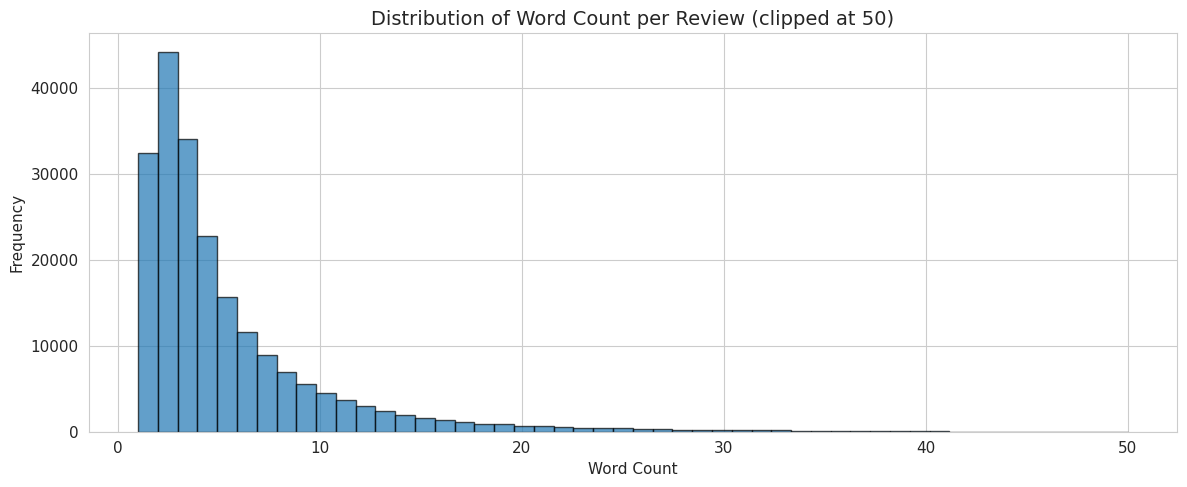

In [6]:
# Word count distribution
df['word_count'] = df['final_text'].apply(lambda x: len(str(x).split()))

print('Word count statistics:')
print(df['word_count'].describe().round(2))

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
df['word_count'].clip(upper=50).hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
ax.set_title('Distribution of Word Count per Review (clipped at 50)', fontsize=14)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [7]:
# Sample some cleaned reviews
print('Sample cleaned reviews:')
print('=' * 80)
for _, row in df[['final_text', 'sentiment']].sample(5, random_state=42).iterrows():
    print(f'  [{row["sentiment"]}] {row["final_text"][:100]}')
    print()

Sample cleaned reviews:
  [positive] mantap

  [negative] iklan

  [positive] mudah bayar pesan makan

  [positive] simpel bantu

  [positive] cepat masalah selesai sesuai kasih uang bantu



## 4. Build Bag of Words Model

We use `CountVectorizer` from scikit-learn to convert the `final_text` column into a term-document matrix.

Each row = one review, each column = one word in the vocabulary, each cell = count of that word in that review.

In [8]:
# Initialize CountVectorizer
# Since text is already preprocessed (lowercased, tokenized, stopwords removed, stemmed),
# we use minimal settings here.
bow_vectorizer = CountVectorizer(
    analyzer='word',        # tokenize by word
    token_pattern=r'\b\w+\b',  # match word boundaries
    min_df=2,               # ignore words appearing in fewer than 2 documents
    max_df=0.95,            # ignore words appearing in more than 95% of documents
)

# Fit and transform the cleaned text
bow_matrix = bow_vectorizer.fit_transform(df['final_text'])

print(f'BoW Matrix Shape : {bow_matrix.shape}')
print(f'  - Documents    : {bow_matrix.shape[0]:,}')
print(f'  - Vocabulary   : {bow_matrix.shape[1]:,} unique terms')
print(f'  - Non-zero     : {bow_matrix.nnz:,} entries')
print(f'  - Sparsity     : {(1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])) * 100:.4f}%')

BoW Matrix Shape : (209311, 12297)
  - Documents    : 209,311
  - Vocabulary   : 12,297 unique terms
  - Non-zero     : 970,977 entries
  - Sparsity     : 99.9623%


## 5. Inspect BoW Vocabulary

In [9]:
# Get vocabulary (word -> index mapping)
vocab = bow_vectorizer.get_feature_names_out()
print(f'Total vocabulary size: {len(vocab):,}')
print(f'\nFirst 20 terms : {list(vocab[:20])}')
print(f'Last 20 terms  : {list(vocab[-20:])}')

Total vocabulary size: 12,297

First 20 terms : ['a', 'aa', 'aaa', 'aad', 'aada', 'aah', 'aahhh', 'aaja', 'aaman', 'aamiin', 'aamiinn', 'aaminn', 'aaneh', 'aangat', 'aaplikasi', 'aaya', 'ab', 'aba', 'abad', 'abadi']
Last 20 terms  : ['yuhuuu', 'yuhuuuu', 'yuk', 'yuo', 'yutub', 'yutuber', 'yuy', 'yv', 'yy', 'zakat', 'zaman', 'zc', 'zero', 'zip', 'zolim', 'zone', 'zong', 'zonk', 'zoonk', 'zy']


In [10]:
# Compute total term frequencies across all documents
term_freq = np.asarray(bow_matrix.sum(axis=0)).flatten()

# Create a DataFrame of term frequencies
df_freq = pd.DataFrame({
    'term': vocab,
    'frequency': term_freq
}).sort_values('frequency', ascending=False).reset_index(drop=True)

print('Top 30 most frequent terms (BoW):')
print(df_freq.head(30).to_string(index=False))

Top 30 most frequent terms (BoW):
     term  frequency
    mudah      25831
    bagus      24547
transaksi      20428
    bantu      19798
    pakai      19626
    saldo      18604
    masuk      17561
   banget      17009
    bayar      15532
   mantap      13779
 transfer      13138
      top      11602
    cepat      11547
    kasih      11320
     uang      10780
   pinjam       8904
     aman       7654
     akun       7197
     baik       7145
     beli       6935
     moga       6861
     kalo       6635
     suka       6072
     bank       5920
    ribet       5761
   gratis       5742
    murah       5576
     coba       5564
   terima       5548
     dana       5397


## 6. Visualize Top Terms

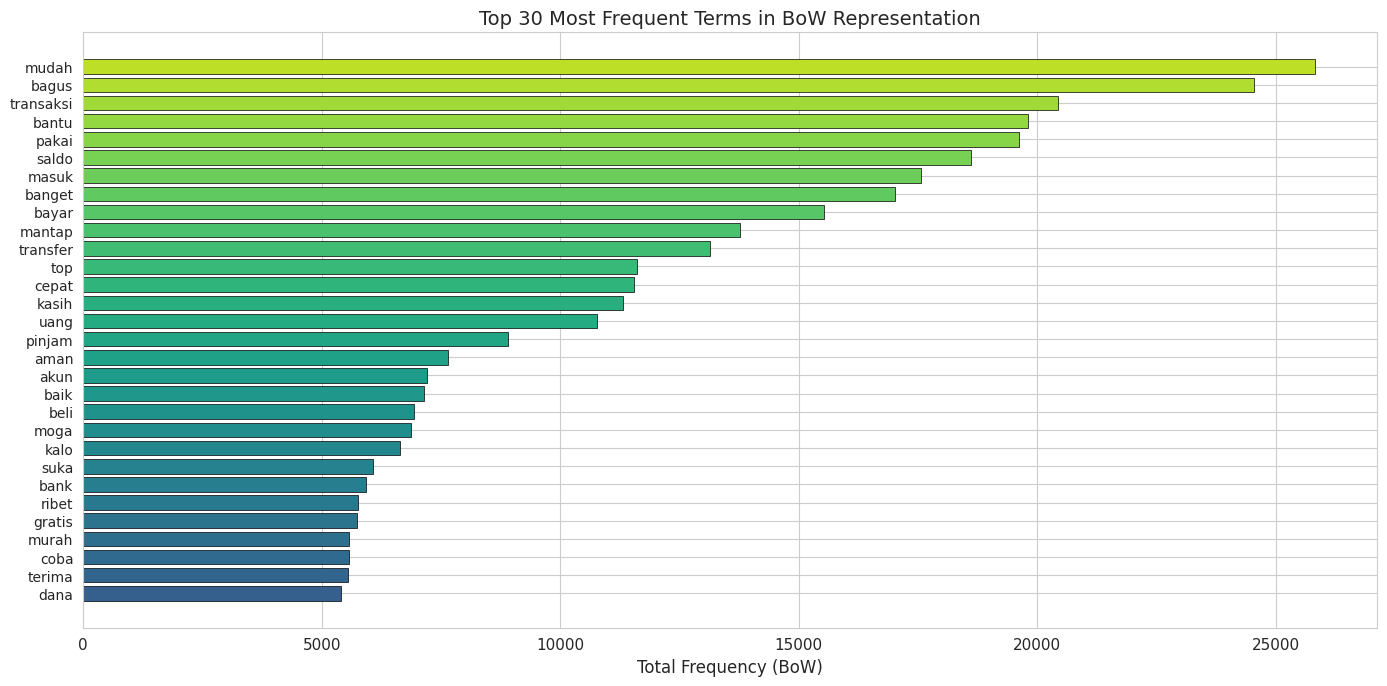

In [11]:
# Top 30 terms bar chart
top_n = 30
top_terms = df_freq.head(top_n)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    top_terms['term'][::-1],
    top_terms['frequency'][::-1],
    color=plt.cm.viridis(np.linspace(0.3, 0.9, top_n)),
    edgecolor='black', linewidth=0.5
)
ax.set_xlabel('Total Frequency (BoW)', fontsize=12)
ax.set_title(f'Top {top_n} Most Frequent Terms in BoW Representation', fontsize=14)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

Sentiment labels: ['negative', 'positive', 'neutral']



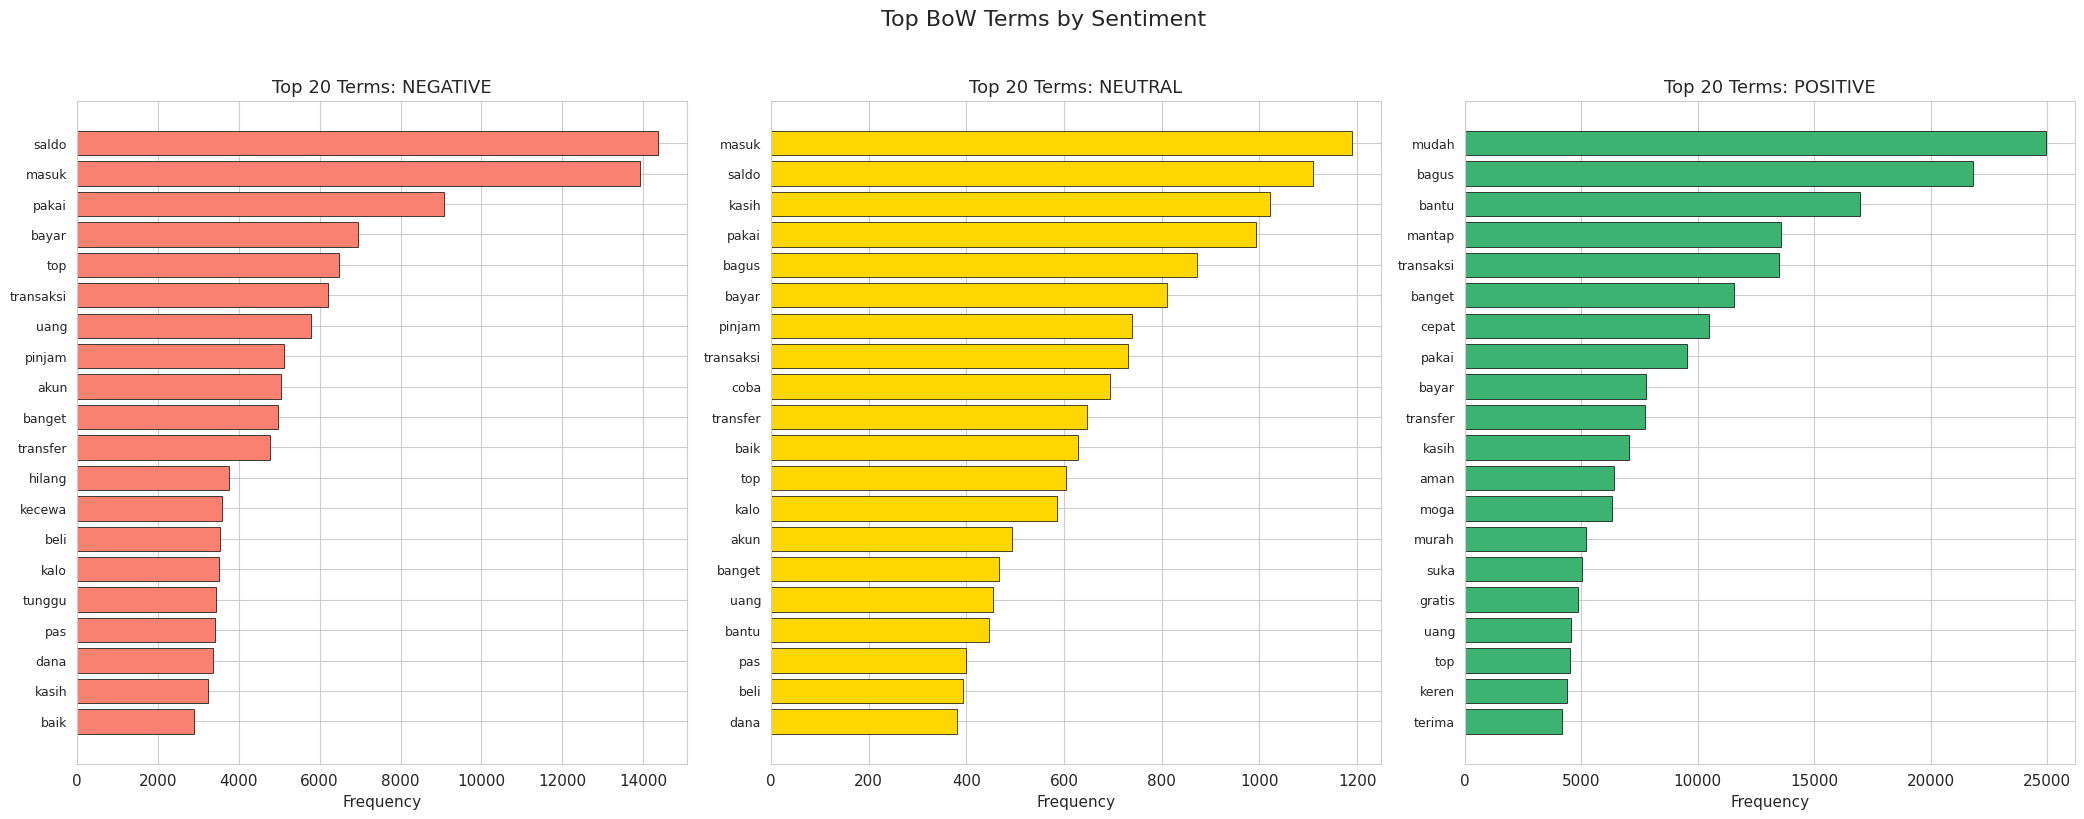

In [12]:
# Top terms by sentiment
sentiments = df['sentiment'].unique()
print(f'Sentiment labels: {list(sentiments)}')
print()

fig, axes = plt.subplots(1, len(sentiments), figsize=(7 * len(sentiments), 8))
if len(sentiments) == 1:
    axes = [axes]

for ax, sentiment in zip(axes, sorted(sentiments)):
    mask = df['sentiment'] == sentiment
    subset_matrix = bow_matrix[mask.values]
    subset_freq = np.asarray(subset_matrix.sum(axis=0)).flatten()

    top_idx = subset_freq.argsort()[::-1][:20]
    top_words = vocab[top_idx]
    top_counts = subset_freq[top_idx]

    ax.barh(top_words[::-1], top_counts[::-1],
            color='salmon' if sentiment == 'negative' else ('gold' if sentiment == 'neutral' else 'mediumseagreen'),
            edgecolor='black', linewidth=0.5)
    ax.set_title(f'Top 20 Terms: {sentiment.upper()}', fontsize=13)
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Top BoW Terms by Sentiment', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7. BoW Matrix Preview

In [15]:
# Find top 20 most frequent terms
term_freq = np.asarray(bow_matrix.sum(axis=0)).flatten()
top_20_idx = term_freq.argsort()[::-1][:20]
top_20_terms = vocab[top_20_idx]

# Preview BoW matrix using top 20 most frequent terms
preview_df = pd.DataFrame(
    bow_matrix[:10, top_20_idx].toarray(),
    columns=top_20_terms
)
print('BoW Matrix Preview (10 rows x top 20 frequent terms):')
preview_df

BoW Matrix Preview (10 rows x top 20 frequent terms):


,mudah,bagus,transaksi,bantu,pakai,saldo,masuk,banget,bayar,mantap,transfer,top,cepat,kasih,uang,pinjam,aman,akun,baik,beli
0,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
9,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 8. Export BoW Artifacts

Save the BoW matrix and vocabulary for downstream use (TF-IDF, model training).

In [14]:
import pickle

# Save sparse BoW matrix
save_npz('bow_matrix.npz', bow_matrix)
print('Saved: bow_matrix.npz')

# Save vocabulary list
pd.DataFrame({'term': vocab}).to_csv('/content/drive/MyDrive/Tugas 1/Dataset/bow_vocabulary.csv', index=False)
print('Saved: bow_vocabulary.csv')

# Save term frequency table
df_freq.to_csv('bow_term_frequencies.csv', index=False)
print('Saved: bow_term_frequencies.csv')

# Save the fitted vectorizer (for reuse in TF-IDF or prediction pipeline)
with open('bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)
print('Saved: bow_vectorizer.pkl')

print(f'\nBoW extraction complete.')
print(f'  Documents  : {bow_matrix.shape[0]:,}')
print(f'  Vocabulary : {bow_matrix.shape[1]:,} terms')
print(f'  Matrix     : {bow_matrix.nnz:,} non-zero entries')

Saved: bow_matrix.npz
Saved: bow_vocabulary.csv
Saved: bow_term_frequencies.csv
Saved: bow_vectorizer.pkl

BoW extraction complete.
  Documents  : 209,311
  Vocabulary : 12,297 terms
  Matrix     : 970,977 non-zero entries
